## Computational Aspects of Complex Reflection Groups

Götz Pfeiffer - University of Galway

# Draft: Coset Enumeration on Union-Find

<div class="alert alert-danger">

**Draft.**  This notebook is a draft, not part of the collection.  It works out an alternative to the coset enumeration of Part 3, built directly on Union-Find, as a basis for deciding whether Part 3 should be rewritten this way.

</div>

## What Would Change in Part 3

* **Kept:** the introduction to complex reflection groups, the section on Union-Find, the presentations and their relation variants, the example $G_{12}$, and the exercises.
* **Replaced:** the sections *Data Nodes* (the `Item` objects) and *Smart Nodes* (the `Node` objects with their `flat` pointers), and the node-based enumerator.
* **Instead:** cosets are **integers** $1, 2, 3, \dots$, the coset table is an array `next[x][s]`, with $0$ for "not yet known", and a `parent` array is the Union-Find forest on the cosets.
* **The algorithm stays the same:** the same strategy, the same definitions, the same coincidences, and, as we check below, exactly the same coset tables.  What changes is the way it is put together:
  * the main loop is the **orbit algorithm**, over coset numbers;
  * coincidences are handled by **Union-Find**, with a **queue** of pending coincidences in place of the recursion through `setImage`, `mergeNodes` and `updateEdge`;
  * so Todd-Coxeter becomes: *orbit algorithm + Union-Find + relation variants*, three ingredients that the notebooks introduce separately.
* **And Part 4** then only needs to swap the Union-Find for its linear version.

* **Gained:** a simpler structure (one loop instead of three mutually recursive functions), no deep recursion on large collapses, and speed: on the regular representation of $M_{12}$, about one second instead of several minutes (see the comparison at the end; most of the difference comes from a quadratic membership test in the old main loop).
* **Lost, and recovered:** the `Node` objects, which print nicely and carry their own data.  Here, the data lives in arrays, including a list `word` of the words that defined the cosets.  A thin `Coset` handle (see *Cosets as Objects* below) gives cosets their object behaviour back, so that the orbit machinery of Part 1 applies to them.

### An Alternative Design Route

* Throughout the notebooks, the recipe is: define an action on your kind of objects, and the orbit algorithm does the rest.  It relies on being able to tell whether a new object has been seen before: `z in list`, or a dictionary lookup.
* Cosets $Hw$ are different: whether $Hw = Hw'$ is exactly what is not known, and finding it out is the purpose of the enumeration.  So a coset cannot carry its own identity.  It can only be a **name**, here a number, whose equality with other names is decided later, by **Union-Find**.
* This suggests an alternative design route: simplify the objects to their ids, and express the group action as plain permutations of those ids.  `orbit_with_images` in Part 1 prototypes exactly this: it replaces the orbit by the numbers $1, \dots, n$, and the generators by their image lists.

In [1]:
using OrbitAl: Perm, PermGp, sizeOfGroup, plot_edges
using OrbitAl: presentations
using OrbitAl.variants: variantsRelations
using Graphs, GraphPlot
import Cairo, Fontconfig
import OrbitAl

## The Coset Table

* Recall that a presentation `genrel` of a group $G$ has a list `gens` of generators $S = S^{-1}$, with `invr[s]` the inverse of `s`, a list `rels` of relations, and a list `sbgp` of words generating a subgroup $H$.
* A **coset table** lists, for each coset $x$ found so far and each generator $s$, the coset $x.s$, or $0$ if it is not known yet.
* Cosets that turn out to be equal are merged.  A Union-Find forest on the cosets keeps track of that: `parent[x] == x` if $x$ is **active**, and otherwise `parent[x]` points towards the active coset that $x$ has been merged into.

In [2]:
mutable struct CosetTable
    next::Vector{Vector{Int}}             # next[x][s], 0 = not yet known
    parent::Vector{Int}                   # the Union-Find forest on the cosets
    word::Vector{Vector{Int}}             # the word that defined each coset
    invr::Vector{Int}                     # invr[s] is the inverse of s
    variants::Vector{Vector{Vector{Int}}} # the relation variants, see below
    active::Int                           # the number of active cosets
end

CosetTable(genrel) = CosetTable([], [], [], genrel.invr, variantsRelations(genrel), 0)

CosetTable

<div class="alert alert-warning">

<img src="images/julia.png" alt="julia" width="30">

* `Vector{Vector{Int}}` is a list of lists of integers: `next[x]` is the row of coset `x`, and `next[x][s]` its entry for generator `s`.

</div>

* `find` follows the parent pointers to the active coset, as in Part 3, and `image` looks up $x.s$, as an active coset, or $0$.

In [3]:
function find(T::CosetTable, x)
    while T.parent[x] != x
        x = T.parent[x]
    end
    return x
end

is_active(T, x) = T.parent[x] == x

image(T, x, s) = (y = T.next[x][s]; y == 0 ? 0 : find(T, y))

image (generic function with 1 method)

* A new coset $y = x.s$ gets a new number, an empty row, and the word of $x$ followed by $s$.  Its entry for $s^{-1}$ is $x$.

In [4]:
function newcoset!(T, word)
    push!(T.next, zeros(Int, length(T.invr)))
    push!(T.parent, length(T.parent) + 1)
    push!(T.word, word)
    T.active += 1
    return length(T.parent)
end

function sprout!(T, x, s)
    y = newcoset!(T, [T.word[x]; s])
    T.next[x][s] = y
    T.next[y][T.invr[s]] = x
    return y
end

sprout! (generic function with 1 method)

* For display, a coset table lists its active cosets, with the word that defined them, and their images.

In [5]:
function Base.show(io::IO, ::MIME"text/plain", T::CosetTable)
    acti = filter(x -> is_active(T, x), eachindex(T.parent))
    println(io, "CosetTable: ", length(acti), " active of ", length(T.parent), " cosets")
    for x in acti[1:min(end, 12)]
        println(io, lpad(x, 4), ": ", rpad(join(T.word[x]), 10), [image(T, x, s) for s in eachindex(T.invr)])
    end
    length(acti) > 12 && print(io, "   ...")
end

<div class="alert alert-warning">

<img src="images/julia.png" alt="julia" width="30">

* Defining `Base.show` with its full name adds a method to it without `import Base: show` first.

</div>

### Actions on Words

* As in Part 3, there are two ways of applying a word to a coset: a **partial** action, which gives up (returns $0$) when it meets an unknown image, and a **defining** action, which defines new cosets when necessary.

In [6]:
function underWordPartial(T, x, word)
    for s in word
        x = image(T, x, s)
        x == 0 && return 0
    end
    return x
end

function underWordSprout!(T, x, word)
    for s in word
        y = image(T, x, s)
        x = y == 0 ? sprout!(T, x, s) : y
    end
    return x
end

underWordSprout! (generic function with 1 method)

## Coincidences

* To set $x.s = y$ means to set two entries of the table: $x.s = y$ and $y.s^{-1} = x$.
* If an entry is already set, to a different coset, then the two cosets are equal: a **coincidence**.
* Merging two cosets means: make the larger one point to the smaller one (Union-Find), and move all entries of its row over to the smaller one, which can cause further coincidences.
* The pending coincidences are kept in a queue.  The loop over the queue grows while it runs, just like the list in the orbit algorithm.

<div class="alert alert-info">

**Coincidence Procedure**
* **Input:** a coset table, and a new edge $x \stackrel{s}{\longrightarrow} y$.
* **1.** Set $x.s = y$ and $y.s^{-1} = x$.  Each clash with an existing entry is a pair of equal cosets: put it in the **queue**.
* **2.** For each pair $(a, b)$ in the queue: replace $a$ and $b$ by their active cosets.  If they are different, with $a < b$, then **unite** them: $b$ now points to $a$, and each entry $b.t$ is moved over to $a$ as in step 1, possibly adding further pairs to the queue.
* **3.** When the queue is exhausted, the table is consistent again.

</div>

In [7]:
# x.s = y and y.s^-1 = x; a clash with an existing entry is a coincidence
function link!(T, x, s, y, queue)
    for (u, t, v) in ((x, s, y), (y, T.invr[s], x))
        u, v = find(T, u), find(T, v)
        w = T.next[u][t]
        w == 0 ? (T.next[u][t] = v) : push!(queue, (v, w))
    end
end

function updateEdge!(T, x, s, y)
    queue = Tuple{Int,Int}[]
    link!(T, x, s, y, queue)
    for (a, b) in queue                        # the queue grows while we loop
        a, b = find(T, a), find(T, b)
        a == b && continue
        a > b && ((a, b) = (b, a))
        T.parent[b] = a                        # unite: b is no longer active
        T.active -= 1
        for (t, y) in enumerate(T.next[b])     # move b's edges over to a
            y == 0 || link!(T, a, t, y, queue)
        end
    end
end

updateEdge! (generic function with 1 method)

<div class="alert alert-warning">

<img src="images/julia.png" alt="julia" width="30">

* `(u, t, v) in ((x, s, y), (y, T.invr[s], x))` loops over a tuple of tuples, taking each apart into three variables.
* `for (a, b) in queue` is safe while `push!` adds to `queue`: like the list of the orbit algorithm, the loop sees the new entries.

</div>

## Relations

* A relation $l = r$ is a relator $w = l r^{-1}$, a word that should act trivially on every coset.
* If $w = u s v$ for a generator $s$, then $s = u^{-1} v^{-1}$, and so $x.s = x.(v u)^{-1}$ for each coset $x$.  These words $(vu)^{-1}$ are the **variants** of the relations for $s$, computed by `variantsRelations` (as in Part 3).
* For example, here are the variants for the first generator of $G_{12}$:

In [8]:
G = presentations.G12
G.rels, variantsRelations(G)[1]

([[[1, 2, 3, 1], [2, 3, 1, 2]], [[2, 3, 1, 2], [3, 1, 2, 3]]], [[3, 2, 1, 2, 3, 1, 2], [3, 2, 3, 1, 2, 3, 2], [2, 3, 1, 2, 1, 3, 2], [2, 1, 3, 2, 1, 2, 3], [2, 3, 2, 1, 3, 2, 3]])

* To **trace** a word $w$ from coset $x$ means to make sure that $x.w = x$, defining new cosets as necessary.  The words generating the subgroup $H$ are traced from coset $1$, which stands for $H$.
* To **finalize** coset $x$ under generator $s$: try each variant $w$ for $s$, and if $x.w$ is already known, set $x.s = x.w$, possibly causing coincidences.  If $x.s$ is still unknown after that, define it as a new coset.

In [9]:
function trace!(T, x, word)
    y = underWordSprout!(T, x, word[1:end-1])
    updateEdge!(T, y, word[end], x)
end

function finalize!(T, x, s)
    for variant in T.variants[s]
        is_active(T, x) || return
        y = underWordPartial(T, x, variant)
        y == 0 || updateEdge!(T, x, s, y)
    end
    is_active(T, x) && T.next[x][s] == 0 && sprout!(T, x, s)
end

finalize! (generic function with 1 method)

## Enumerate!

* The enumeration is now an orbit algorithm over the coset numbers: start with coset $1$ and the subgroup tables, then finalize each coset in turn under each generator, while new cosets are being defined.

<div class="alert alert-info">

**Coset Enumeration**
* **Input:** a presentation $\langle S \mid R \rangle$ of a group $G$, and words generating a subgroup $H$.
* **Output:** the coset table of $H$ in $G$, if $|G : H|$ is finite.
* **1. Initialize** the table with coset $1$, and trace the generators of $H$ from coset $1$.
* **2. Loop** over the cosets $x = 1, 2, \dots$, as long as there are more, and finalize $x$ under each $s \in S$.
* **3. Return** the table.  Its active cosets are the cosets of $H$ in $G$.

</div>

In [10]:
function coset_table(genrel, sbgp)
    T = CosetTable(genrel)
    x = newcoset!(T, Int[])
    for word in sbgp
        trace!(T, x, word)
    end
    x = 0
    while x < length(T.parent)                # the table grows while we loop
        x += 1
        for s in genrel.gens
            finalize!(T, x, s)
        end
    end
    return T
end

coset_table (generic function with 1 method)

* A loop `for x in 1:length(T.parent)` would not do here: its range is fixed when the loop starts.  Hence the `while` loop.
* Inactive cosets are visited too, but `finalize!` returns immediately for them.

## Test Drive

* $G_{12}$, over the subgroup generated by its first generator:

In [11]:
T = coset_table(G, G.sbgp)

CosetTable: 24 active of 24 cosets
   1:           [1, 2, 3]
   2: 2         [4, 1, 5]
   3: 3         [6, 7, 1]
   4: 21        [2, 8, 9]
   5: 23        [10, 11, 2]
   6: 31        [3, 12, 13]
   7: 32        [14, 3, 15]
   8: 212       [16, 4, 17]
   9: 213       [18, 14, 4]
  10: 231       [5, 10, 12]
  11: 232       [15, 5, 19]
  12: 312       [17, 6, 10]
   ...

* The active cosets, renumbered $1, \dots, n$, and the permutations of the generators on them:

In [12]:
function perms(T)
    acti = filter(x -> is_active(T, x), eachindex(T.parent))
    idx = Dict(x => i for (i, x) in enumerate(acti))
    [Perm([idx[image(T, x, s)] for x in acti]) for s in eachindex(T.invr)]
end

gens = perms(T)
sizeOfGroup(PermGp(gens, one(gens[1])))

48

* And the action graph:

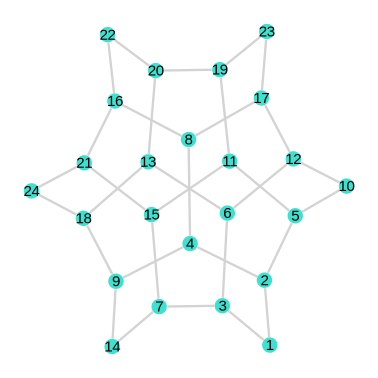

In [13]:
elist = union([(i, j) for a in gens for (i, j) in enumerate(a.list) if i != j])
plot_edges(elist)

* $G(3,3,3)$, over the subgroup $\langle t_0, t_1, t_2 \rangle$, as in Part 4:

In [14]:
G = presentations.G333
T = coset_table(G, G.sbgp)

CosetTable: 9 active of 9 cosets
   1:           [1, 1, 1, 2]
   2: 4         [3, 4, 5, 1]
   3: 41        [2, 6, 7, 3]
   4: 42        [7, 2, 6, 4]
   5: 43        [6, 7, 2, 5]
   6: 412       [5, 3, 4, 8]
   7: 413       [4, 5, 3, 9]
   8: 4124      [8, 8, 8, 6]
   9: 4134      [9, 9, 9, 7]


* The same nine cosets appear in the hand-made coset table of the Hecke algebra of $G(3,3,3)$ in Part 4 (with generator 4 as $s_3$, and generators $1, 2, 3$ as $t_0, t_1, t_2$).  The words of $x_1, \dots, x_4$ agree exactly: $s_3$, $s_3 t_0$, $s_3 t_1$, $s_3 t_2$.  The later ones differ, since the hand-made table defines its cosets in a different order.

In [15]:
gens = perms(T)
sizeOfGroup(PermGp(gens, one(gens[1])))

54

## Cosets as Objects

* The motto of the notebooks is: if you can define a group action on your kind of objects, then all the orbit machinery applies.  Here, the cosets have become mere numbers.  But a thin **handle** gives them back their behaviour: a `Coset` is a reference to a table, together with a coset number.
* The data stays in the table.  A `Coset` knows where to find it: its word, its images, and which active coset it stands for.

In [16]:
struct Coset
    table::CosetTable
    id::Int
end

active(c::Coset) = find(c.table, c.id)          # the active coset that c stands for
word(c::Coset) = c.table.word[active(c)]

function Base.:^(c::Coset, s::Int)              # the coset c.s, or nothing if unknown
    y = image(c.table, active(c), s)
    y == 0 ? nothing : Coset(c.table, y)
end

Base.:(==)(c::Coset, d::Coset) = c.table === d.table && active(c) == active(d)
Base.hash(c::Coset, h::UInt) = hash(active(c), h)
Base.isless(c::Coset, d::Coset) = active(c) < active(d)
Base.show(io::IO, c::Coset) = print(io, "Coset(", active(c), ", word = ", join(word(c)), ")")

<div class="alert alert-warning">

<img src="images/julia.png" alt="julia" width="30">

* `Base.:^` and `Base.:(==)` are the full names of the operators `^` and `==`: defining them adds methods for `Coset`s.
* `c.table === d.table` tests whether two cosets refer to the very same table object, not just to equal ones.

</div>

* Two cosets are equal if they stand for the same active coset, so they are compared, and hashed, by `active(c)`: Union-Find provides the equality test that cosets lack.
* For example, in $G(3,3,3)$:

In [17]:
G = presentations.G333
T = coset_table(G, G.sbgp)
x = Coset(T, 1)
x^4, (x^4)^1, ((x^4)^1)^4

(Coset(2, word = 4), Coset(3, word = 41), Coset(3, word = 41))

* With `onCosets` as action function, the orbit algorithm of Part 1 applies to cosets, like to any other objects.  The orbit of the trivial coset under the generators is the set of all cosets:

In [18]:
onCosets(c, s) = c^s
orb = OrbitAl.orbit(G.gens, x, onCosets)
length(orb) == T.active

true

* And `orbit_with_words` gives each coset a word, that is, a **Schreier transversal** of the subgroup, as needed for the Reidemeister-Schreier method:

In [19]:
OrbitAl.orbit_with_words(G.gens, x, onCosets).words

9-element Vector{Vector{Int64}}:
 []
 [4]
 [4, 1]
 [4, 2]
 [4, 3]
 [4, 1, 2]
 [4, 1, 3]
 [4, 1, 2, 4]
 [4, 1, 3, 4]

* So the cosets do form an orbit, in exactly the sense of Part 1.  What the enumeration adds is the step *before* that: deciding which cosets are equal.

## Comparison with Part 3

* On every presentation in `presentations`, the two enumerators produce the same coset table, up to the numbering of the cosets:

In [20]:
function perms_nodes(list)
    acti = filter(OrbitAl.enumerator.is_active, list)
    idx = Dict(node.idx => i for (i, node) in enumerate(acti))
    [Perm([idx[OrbitAl.enumerator.flat(node.next[s]).idx] for node in acti]) for s in eachindex(acti[1].next)]
end

pres_names = [:A2, :A3, :G4, :G5, :G6, :G7, :G8, :G9, :G10, :G11, :G12, :G13, :G17, :G24, :G29, :G333, :M12, :J1]
for name in pres_names
    G = getfield(presentations, name)
    T = coset_table(G, G.sbgp)
    same = perms(T) == perms_nodes(OrbitAl.enumerator.coset_table(G, G.sbgp))
    println(rpad(name, 5), "index ", lpad(T.active, 4), ", cosets defined ", lpad(length(T.parent), 5), ", same table: ", same)
end

A2   index    3, cosets defined     3, same table: true
A3   index    4, cosets defined     4, same table: true
G4   index    8, cosets defined     8, same table: true
G5   index   24, cosets defined    24, same table: true
G6   index   16, cosets defined    16, same table: true
G7   index   48, cosets defined    52, same table: true
G8   index   24, cosets defined    24, same table: true
G9   index   48, cosets defined    48, same table: true
G10  index   72, cosets defined    72, same table: true
G11  index  144, cosets defined   159, same table: true
G12  index   24, cosets defined    24, same table: true
G13  index   48, cosets defined    52, same table: true
G17  index  240, cosets defined   240, same table: true
G24  index   42, cosets defined    42, same table: true
G29  index  160, cosets defined   160, same table: true
G333 index    9, cosets defined     9, same table: true
M12  index  144, cosets defined  1260, same table: true
J1   index  266, cosets defined  5128, same tabl

* For larger enumerations, take the trivial subgroup: the cosets are then the elements of the group.

In [21]:
for name in [:G29, :M12, :J1]
    G = getfield(presentations, name)
    t = @elapsed T = coset_table(G, Vector{Int}[])
    println(rpad(name, 5), "order ", lpad(T.active, 6), ", cosets defined ", lpad(length(T.parent), 6), ", ", round(t, digits = 2), "s")
end

G29  order   7680, cosets defined   7699, 0.01s
M12  order  95040, cosets defined 194311, 0.74s
J1   order 175560, cosets defined 810704, 3.36s


* For comparison, the node-based enumerator of Part 3 took about $218$s for $M_{12}$ (measured once, not rerun here).  For $G_{29}$, it is run in the next cell.  Most of that difference comes from its main loop, `orbitx`, which tests `z in list` for every coset and generator: a linear search, which makes the whole enumeration quadratic.

In [22]:
G = presentations.G29
t = @elapsed list = OrbitAl.enumerator.coset_table(G, Vector{Int}[])
count(OrbitAl.enumerator.is_active, list), round(t, digits = 2)

(7680, 0.09)

## Remarks

* **Termination.**  Coset enumeration terminates if the index $|G : H|$ is finite, provided that the strategy is fair: every entry of the table is eventually defined or deduced, and every relator is eventually checked at every coset.  But there is no bound on the number of cosets defined along the way in terms of the index, and whether a finite presentation defines a finite group cannot be decided in general [Neu82], [Sim94], [HEO05].
* **Strategies.**  The strategy here, deducing from all variants of the relations before each definition, is close to the Felsch strategy.  The Haselgrove-Leech-Trotter (HLT) strategy instead defines cosets freely while tracing relators, and typically defines many more cosets, but is cheaper per coset [Sim94], [HEO05].

## Exercises

**Exercise U.1.**  Add path compression (Exercise 3.5) to `find`, and measure the effect on the enumerations over the trivial subgroup.

**Exercise U.2.**  Process the coincidence queue last in, first out, as a stack, instead of first in, first out.  Does the result change?  The number of steps?

**Exercise U.3.**  Write `compact!(T)`, which renumbers the active cosets $1, \dots, n$ and discards the others, during the enumeration, when more than half of the cosets have become inactive.

**Exercise U.4.**  Implement the HLT strategy: for each coset $x$ and each relator $r$, trace $r$ from $x$.  Compare the number of cosets defined with the strategy above, on $M_{12}$ and $J_1$.

**Exercise U.5.**  ($*$) Check whether the strategy above is fair, in the sense of the remark on termination.

## References

As in the preface: [HEO05], [Neu82], [Sim94], and, for Union-Find, [GF64], [Tar75].